# ANN 2 - Regression - Combined Cycle Power Plants

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2025-10-03 23:05:08.914175: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-03 23:05:13.402182: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-03 23:06:17.540803: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.__version__

'2.20.0'

In [3]:
start_time = time.time()

## Part 1 - Data Preprocessing

### Importing the dataset

In [4]:
dataset = pd.read_excel('../Data/Folds5x2_pp.xlsx')
dataset.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


<Axes: >

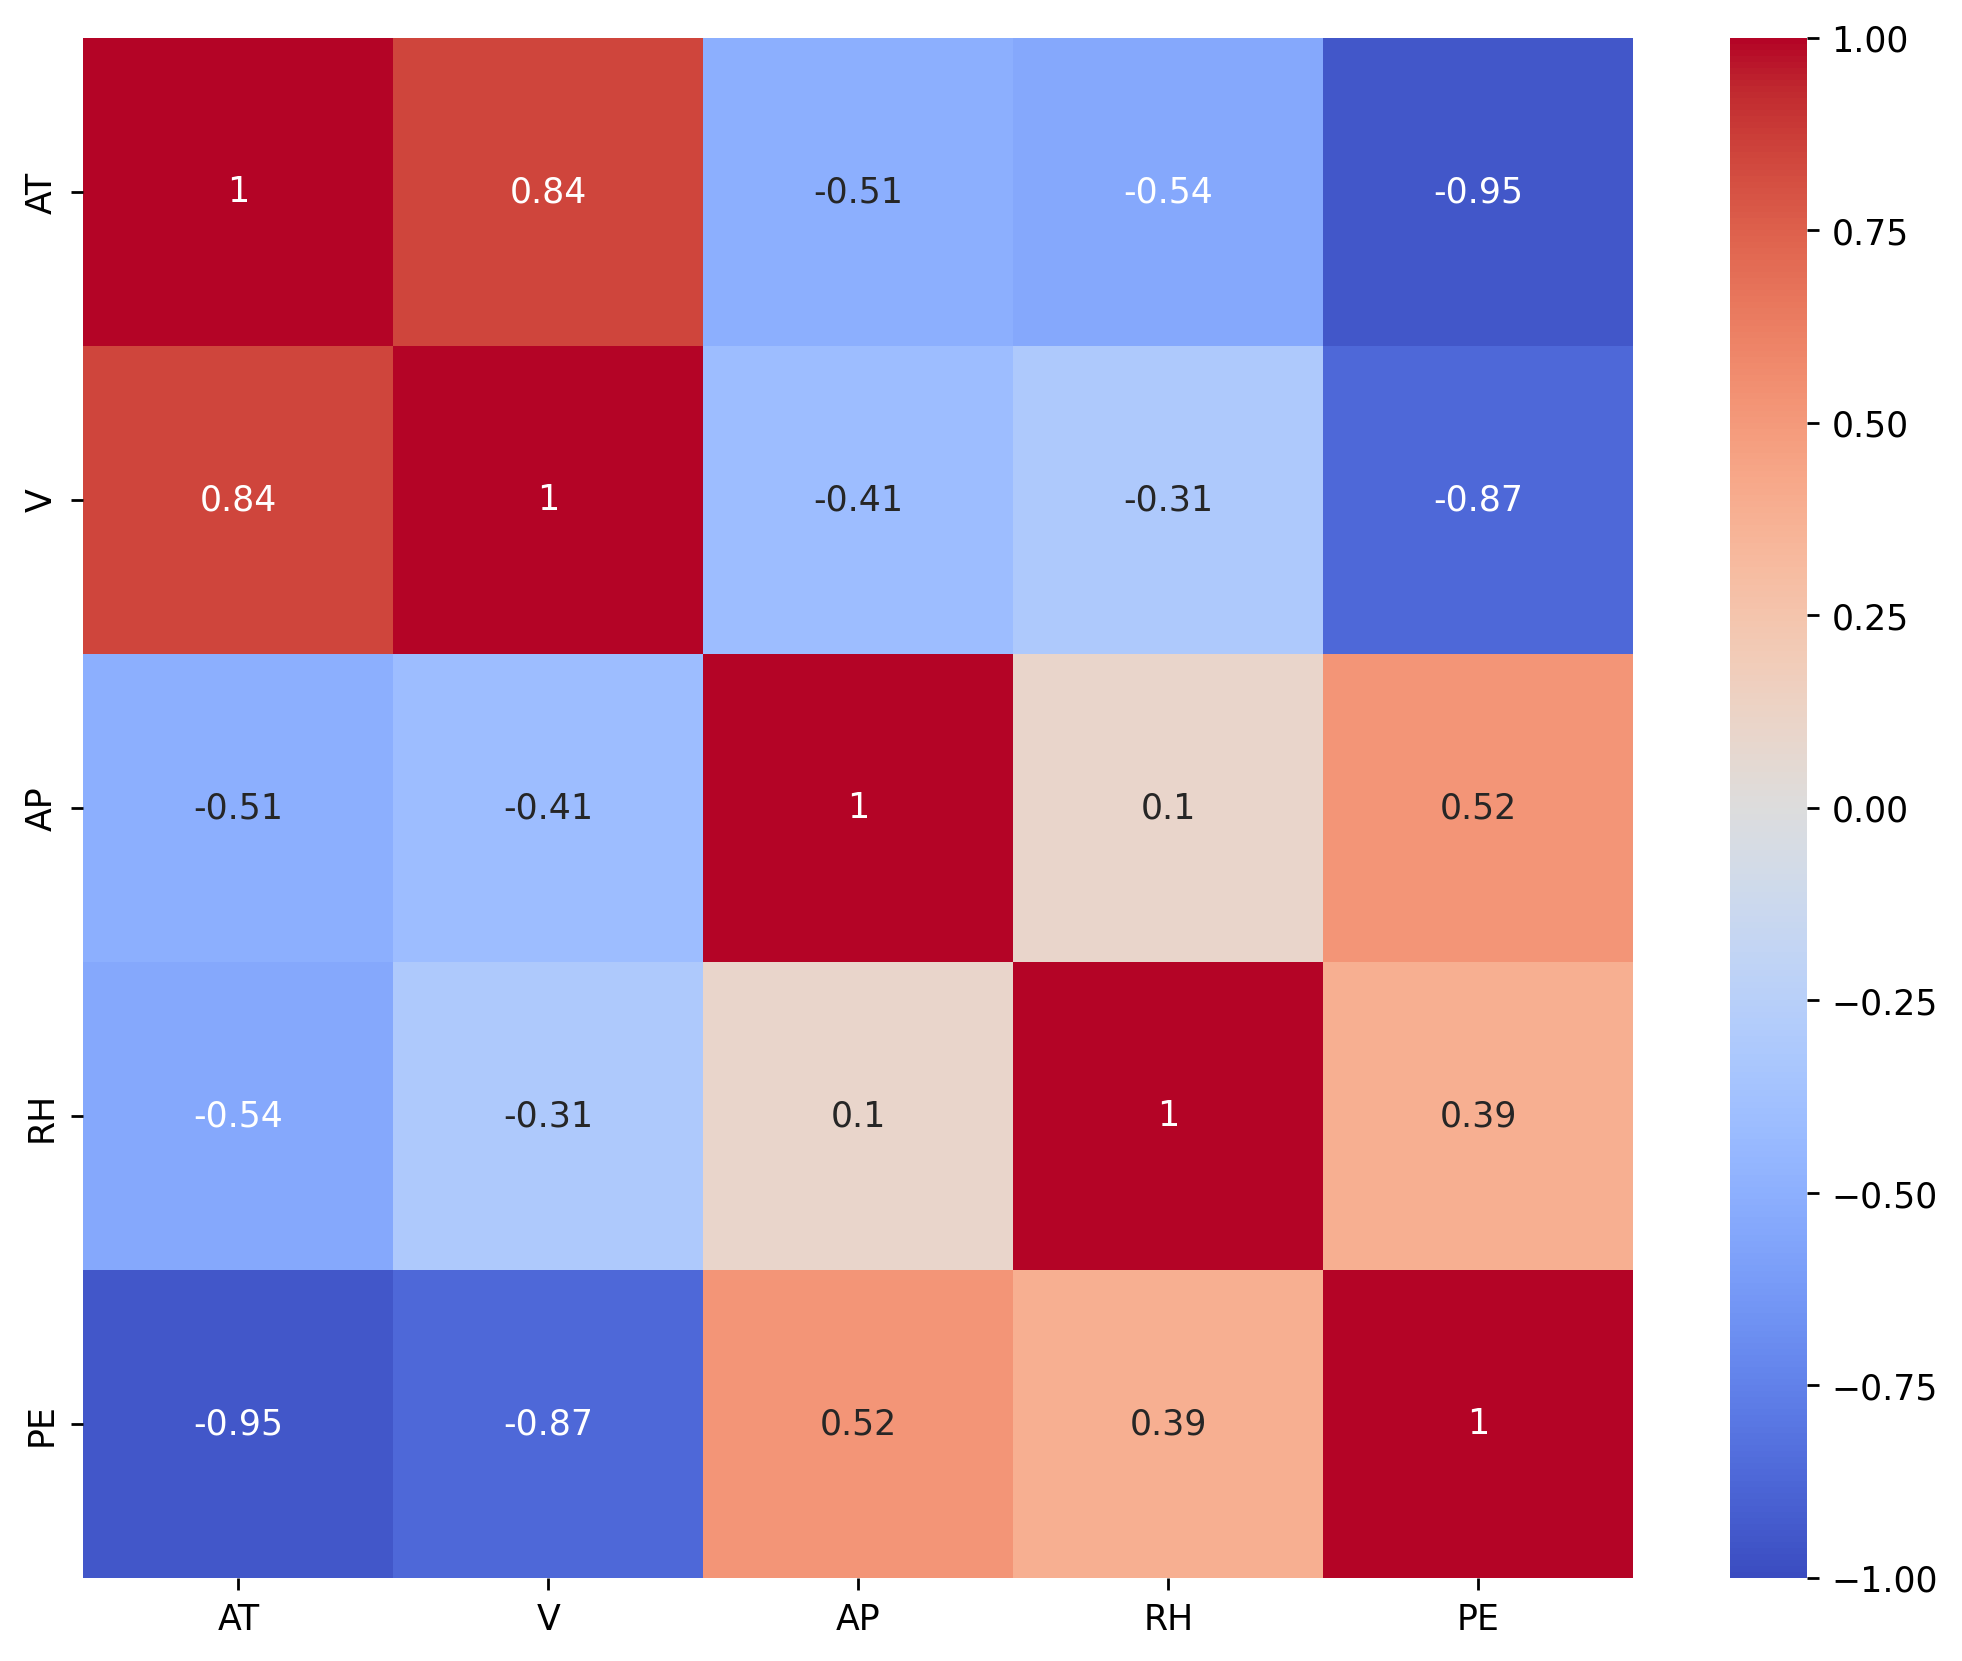

In [5]:
plt.figure(figsize=(10,8), dpi=250)
sns.heatmap(data=dataset.corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm' )

In [6]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Part 2 - Building the ANN

### Initializing the ANN

In [8]:
ann = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [9]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the second hidden layer

In [10]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the output layer

In [11]:
ann.add(tf.keras.layers.Dense(units=1))

## Part 3 - Training the ANN

### Compiling the ANN

In [12]:
ann.compile(optimizer = 'adam', loss = 'mean_squared_error')

I0000 00:00:1759550826.669551    3469 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


### Training the ANN model on the Training set

In [13]:
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100


2025-10-03 23:07:08.178605: I external/local_xla/xla/service/service.cc:163] XLA service 0x79a8d4008020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-03 23:07:08.178666: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-10-03 23:07:08.470612: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-03 23:07:09.495946: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


 43/240 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 77838.3203

I0000 00:00:1759550831.976321    4104 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 25108.3828
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 297.9160
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 287.0243
Epoch 4/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 278.3874
Epoch 5/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 266.8439
Epoch 6/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 249.9482
Epoch 7/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 236.0184
Epoch 8/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 220.8499
Epoch 9/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 203.9256
Epoch 10/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 185.7675
Epoch 11/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 166.8953
Epoch 12/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 146.4524
Epoch 13/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 126.2694
Epoch 14/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 106.3468
Epoch 15/100
240/240 ━━━━

In [14]:
y_pred = ann.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
[[432.18 431.23]
 [463.4  460.01]
 [466.82 461.14]
 ...
 [473.91 473.26]
 [440.86 438.  ]
 [459.98 463.28]]


In [15]:
y_pred = ann.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
my_r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {my_r2:.2f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 4.05
MSE: 25.49
RMSE: 5.05
R2 Score: 0.91


In [16]:
single_input = np.array([[15.75, 52.34, 1015.44, 75.12]])

In [17]:
prediction = ann.predict(single_input)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
[[463.19]]


In [18]:
end_time = time.time()
total_time = end_time - start_time
print(total_time)

79.18952965736389
